# Intraday Reversal and Momentum Around the US Equity Session in Crypto Markets

**Question.** US equity markets show predictable intraday return patterns tied to institutional order flow: half-hour periodicity in the cross-section (Heston, Korajczyk & Sadka 2010), slow-moving-investor autocorrelation (Bogousslavsky 2016), and first-half-hour → last-half-hour momentum in the index (Gao, Han, Li & Zhou 2018). Crypto trades 24/7, but institutional activity concentrates around US equity hours. Do the US open (09:30 ET) and close (16:00 ET) leave a tradeable footprint in crypto returns?

**Tests.**
1. **Spot crypto, close window.** Cross-sectional reversal across 25 spot pairs. Rank on the 15:30–16:00 ET return and hold 16:00–17:00 ET.
2. **Spot crypto, open window.** Same design: rank on 09:30–10:00 and hold 10:00–11:00.
3. **Spot BTC/ETH ETFs (IBIT, FBTC, ETHA, FETH).** BTC-vs-ETH relative momentum into the close, Gao et al. intraday time-series momentum, and a twin-ETF placebo.

**Design rules applied throughout.**
- *Non-overlapping windows.* Every bar is labelled by its open time, and a bar counts toward a window only if its whole interval lies inside the window. Signal windows end before hold windows begin; this is asserted in code.
- *Balanced books.* Cross-sectional portfolios hold an equal number of names on each side, at +50% / −50% gross. Net exposure is asserted to be zero, so beta can't masquerade as alpha.
- *Primary specifications fixed in advance.* Window sweeps are reported separately. They select on the early sample, evaluate on the most recent two years, and report a Deflated Sharpe Ratio for the number of trials.
- *Uncertainty shown.* Every Sharpe ratio is annualised (365 days for crypto, 252 for ETFs) and reported with its standard error.
- *Costs charged on every round trip.* Positions open and close each day, so every day pays commission, half-spread and square-root market impact on both sides.
- *No look-ahead in filters or costs.* The ADV and volatility used for eligibility and cost estimates are lagged one day.

In [88]:
import io
import time
import urllib.error
from concurrent.futures import ThreadPoolExecutor
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import kurtosis, norm, skew

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# ── Data ─────────────────────────────────────────────────────────────────────
# "binance_vision": global Binance spot, public monthly archive (data.binance.vision)
# "binance_us"    : Binance.US REST API (a much thinner venue; capacity results differ)
DATA_SOURCE = "binance_vision"
START       = "2020-09"            # first month (YYYY-MM)
BAR_MIN     = 15                   # bar length, minutes
CACHE_DIR   = Path("data_cache")   # delete to force a fresh download
CACHE_DIR.mkdir(exist_ok=True)

UNIVERSE = {
    "BTC": "BTCUSDT",  "ETH": "ETHUSDT",   "SOL": "SOLUSDT",   "BNB": "BNBUSDT",   "ADA": "ADAUSDT",
    "AVAX": "AVAXUSDT", "NEAR": "NEARUSDT", "ATOM": "ATOMUSDT", "ALGO": "ALGOUSDT", "EGLD": "EGLDUSDT",
    "ICP": "ICPUSDT",  "ROSE": "ROSEUSDT", "CELO": "CELOUSDT", "UNI": "UNIUSDT",   "AAVE": "AAVEUSDT",
    "CRV": "CRVUSDT",  "SUSHI": "SUSHIUSDT", "COMP": "COMPUSDT", "1INCH": "1INCHUSDT", "LINK": "LINKUSDT",
    "GRT": "GRTUSDT",  "FIL": "FILUSDT",   "STORJ": "STORJUSDT", "AXS": "AXSUSDT", "MANA": "MANAUSDT",
}
TIER = {**{k: "large" for k in ["BTC", "ETH", "BNB", "SOL"]},
        **{k: "mid"   for k in ["ADA", "AVAX", "LINK", "UNI", "AAVE", "ATOM", "ALGO", "NEAR",
                                "EGLD", "ICP", "MANA", "AXS"]},
        **{k: "small" for k in ["CRV", "SUSHI", "COMP", "1INCH", "GRT", "FIL", "STORJ", "ROSE", "CELO"]}}

ETF_TICKERS = ["IBIT", "FBTC", "ETHA", "FETH"]

# ── Evaluation ───────────────────────────────────────────────────────────────
ANN_CRYPTO = 365     # crypto trades every calendar day
ANN_ETF    = 252
RECENT_YEARS = 2     # most recent N years = hold-out for sweeps

# ── Portfolio & cost assumptions (all per side unless noted) ─────────────────
LS_FRAC         = 0.10                     # fraction of eligible names in each leg (min 1)
AUM_USD         = 100_000                  # book size for impact
MIN_ADV_USD     = {"binance_vision": 1_000_000, "binance_us": 1_000}[DATA_SOURCE]
COMMISSION_BPS  = 7.5                      # Binance standard taker 10 bps less 25% BNB discount; set for your venue/tier
HALF_SPREAD_BPS = {"large": 1.5, "mid": 4.0, "small": 15.0}   # assumption; cross-checked against Roll (1984) below
IMPACT_Y        = 0.5                      # square-root law: impact = Y · σ_daily · sqrt(order / ADV)
ETF_COST_BPS    = {"regular": 1.0, "after_hours": 5.0}       # spread + fees per side, assumption

## Data

The 15-minute spot klines come from the public Binance archive. Every symbol is quoted in USDT. `quote_volume` (USDT) is the liquidity measure. Downloads are cached in `data_cache/` so reruns are fast.

In [90]:
KLINE_COLS = ["open_time", "open", "high", "low", "close", "volume", "close_time",
              "quote_volume", "num_trades", "taker_base_volume", "taker_quote_volume", "ignore"]
KEEP = ["open", "high", "low", "close", "volume", "quote_volume", "num_trades"]

def _klines_to_df(rows):
    df = pd.DataFrame(rows, columns=KLINE_COLS)
    t = pd.to_numeric(df["open_time"])
    unit = "us" if t.max() > 1e14 else "ms"          # archive switched to microseconds in 2025
    df.index = pd.to_datetime(t, unit=unit, utc=True)
    df = df[KEEP].apply(pd.to_numeric, errors="coerce").sort_index()
    return df[~df.index.duplicated(keep="last")]

def load_binance_vision(symbol):
    last_full = pd.Timestamp.now(tz="UTC").tz_localize(None).to_period("M") - 1

    def fetch(p):
        url = (f"https://data.binance.vision/data/spot/monthly/klines/{symbol}/{BAR_MIN}m/"
               f"{symbol}-{BAR_MIN}m-{p.year}-{p.month:02d}.zip")
        for attempt in range(6):       # retry transient DNS / network errors with backoff
            try:
                with urllib.request.urlopen(url, timeout=60) as r:
                    z = zipfile.ZipFile(io.BytesIO(r.read()))
                break
            except urllib.error.HTTPError as e:
                if e.code == 404:      # pair not listed that month
                    return None
                if attempt == 5:
                    raise
            except (urllib.error.URLError, TimeoutError, ConnectionError):
                if attempt == 5:
                    raise
            time.sleep(2 ** attempt)
        raw_csv = pd.read_csv(z.open(z.namelist()[0]), header=None, dtype=str)
        if not raw_csv.iloc[0, 0].isdigit():             # some files carry a header row
            raw_csv = raw_csv.iloc[1:]
        return _klines_to_df(raw_csv.values.tolist())

    with ThreadPoolExecutor(max_workers=4) as pool:
        frames = [f for f in pool.map(fetch, pd.period_range(START, last_full, freq="M")) if f is not None]
    return pd.concat(frames).sort_index() if frames else pd.DataFrame(columns=KEEP)

def load_binance_us(symbol):
    from binance.client import Client
    rows = Client(tld="us").get_historical_klines(symbol, f"{BAR_MIN}m",
                                                  pd.Period(START).start_time.strftime("%Y-%m-%d"))
    return _klines_to_df(rows)

def load_symbol(symbol):
    path = CACHE_DIR / f"{DATA_SOURCE}_{symbol}_{BAR_MIN}m.pkl"
    if path.exists():
        return pd.read_pickle(path)
    df = {"binance_vision": load_binance_vision, "binance_us": load_binance_us}[DATA_SOURCE](symbol)
    df.to_pickle(path)
    return df

raw = {}
for name, sym in UNIVERSE.items():
    raw[name] = load_symbol(sym)
    print(f"{name:6s} {len(raw[name]):>8,} bars", end=" | " if len(raw) % 5 else "\n")
raw = {k: v[~v.index.duplicated(keep="last")] for k, v in raw.items() if len(v)}

# Full 15-minute grid: a missing bar stays NaN (and so does the return after it)
grid  = pd.date_range(min(v.index.min() for v in raw.values()),
                      max(v.index.max() for v in raw.values()), freq=f"{BAR_MIN}min")
panel = lambda f: pd.DataFrame({k: v[f] for k, v in raw.items()}).reindex(grid)
prices, qvol, ntrades = panel("close"), panel("quote_volume"), panel("num_trades")

ET = "America/New_York"
prices, qvol, ntrades = (x.tz_convert(ET) for x in (prices, qvol, ntrades))
rets = np.log(prices).diff()          # value at bar t = return over [t, t + BAR_MIN)
assert prices.index.is_monotonic_increasing and prices.index.is_unique

# Per-ET-date liquidity and volatility, lagged one day (known before the signal)
day_of  = lambda idx: idx.tz_localize(None).normalize()
ADV     = qvol.groupby(day_of(qvol.index)).sum(min_count=1).rolling(30, min_periods=10).mean().shift(1)
VOL_BPS = (rets.groupby(day_of(rets.index)).sum(min_count=1)
               .rolling(30, min_periods=10).std().shift(1) * 1e4)

LAST_DATE = day_of(prices.index).max()
SPLIT     = LAST_DATE - pd.DateOffset(years=RECENT_YEARS)

listed  = prices.notna()
first   = prices.apply(lambda s: s.first_valid_index())
quality = pd.DataFrame({
    "first bar":        first.dt.date,
    "missing bars %":   pd.Series({c: 100 * (1 - listed[c].sum() / (prices.index >= first[c]).sum())
                                   for c in prices.columns}),
    "zero-trade bars %": 100 * (ntrades.eq(0) & listed).sum() / listed.sum(),
    "ADV, last 30d ($M)": ADV.tail(30).median() / 1e6,
}).round(2).sort_values("ADV, last 30d ($M)", ascending=False)
print(f"Source: {DATA_SOURCE} | {prices.index[0]:%Y-%m-%d} → {prices.index[-1]:%Y-%m-%d} | "
      f"{prices.shape[1]} assets | recent hold-out from {SPLIT:%Y-%m-%d}")
display(quality)

BTC     213,123 bars | ETH     213,123 bars | SOL     213,123 bars | BNB     213,123 bars | ADA     213,123 bars
AVAX    211,081 bars | NEAR    208,975 bars | ATOM    213,123 bars | ALGO    213,123 bars | EGLD    212,919 bars
ICP     188,989 bars | ROSE    205,507 bars | CELO    201,016 bars | UNI     211,575 bars | AAVE    208,887 bars
CRV     213,123 bars | SUSHI   213,079 bars | COMP    213,123 bars | 1INCH   202,086 bars | LINK    213,123 bars
GRT     202,773 bars | FIL     208,831 bars | STORJ   210,447 bars | AXS     206,927 bars | MANA    213,123 bars
Source: binance_vision | 2020-08-31 → 2026-09-30 | 25 assets | recent hold-out from 2024-09-30


,first bar,missing bars %,zero-trade bars %,"ADV, last 30d ($M)"
BTC,2020-08-31,0.04,0.01,1237.13
ETH,2020-08-31,0.04,0.01,760.13
SOL,2020-08-31,0.04,0.01,272.09
BNB,2020-08-31,0.04,0.01,109.34
UNI,2020-09-16,0.04,0.01,46.54
NEAR,2020-10-14,0.04,0.01,45.99
LINK,2020-08-31,0.04,0.01,34.04
ADA,2020-08-31,0.04,0.01,32.77
AVAX,2020-09-22,0.04,0.01,19.22
AAVE,2020-10-14,0.04,0.01,17.42


## Toolkit

All three parts share one set of functions: window returns, portfolio construction, costs and statistics. Each function enforces the rules listed in the design section above.

In [92]:
# ── Windows ──────────────────────────────────────────────────────────────────
def hhmm(s):
    h, m = map(int, s.split(":"))
    return 60 * h + m

def tod(idx):
    return np.asarray(idx.hour * 60 + idx.minute)

def window_sum(r, start, end, bar_len):
    # Sum bar returns whose interval [t, t+len) lies inside [start, end) (ET clock).
    # A date/asset is NaN unless every bar in the window is present.
    t = tod(r.index)
    L = np.asarray(bar_len) if not np.isscalar(bar_len) else bar_len
    mask = (t >= hhmm(start)) & (t + L <= hhmm(end))
    if not mask.any():
        raise ValueError(f"no complete bars inside {start}-{end}")
    sub = r[mask]
    n_bars = len(np.unique(t[mask]))
    return sub.groupby(day_of(sub.index)).sum(min_count=n_bars)

def check_disjoint(sig_win, hold_win):
    assert hhmm(sig_win[1]) <= hhmm(hold_win[0]), f"signal {sig_win} overlaps hold {hold_win}"

# ── Portfolio construction ───────────────────────────────────────────────────
def xs_weights(signal, frac=LS_FRAC, eligible=None, direction=-1):
    # Equal-weight cross-sectional book: k names long, k short, +0.5 / -0.5 gross.
    # direction = -1 → reversal (long losers); +1 → momentum (long winners).
    s = signal if eligible is None else signal.where(eligible)
    n = s.notna().sum(axis=1)
    k = np.floor(frac * n).clip(lower=1)
    r = s.rank(axis=1, method="first")
    top, bottom = r.gt(n - k, axis=0), r.le(k, axis=0)
    w = direction * (top.astype(float) - bottom.astype(float))
    w = w.div(2 * k, axis=0)
    w.loc[n < 2] = 0.0
    w = w.fillna(0.0)
    assert w.sum(axis=1).abs().max() < 1e-9, "book is not dollar-neutral"
    return w

# ── Costs ────────────────────────────────────────────────────────────────────
def round_trip_costs(w, adv, vol_bps, aum=AUM_USD, commission_bps=COMMISSION_BPS,
                     impact_y=IMPACT_Y, impact_mult=1.0):
    # Daily cost (return units) of opening and closing book w: each side pays
    # commission + half-spread + square-root impact.
    a     = w.abs()
    hs    = pd.Series({c: HALF_SPREAD_BPS[TIER.get(c, "mid")] for c in w.columns})
    adv_a = adv.reindex(index=w.index, columns=w.columns)
    vol_a = vol_bps.reindex(index=w.index, columns=w.columns)
    imp   = (impact_mult * impact_y * vol_a * np.sqrt(a * aum / adv_a)).where(a > 0, 0.0)
    out = pd.DataFrame({
        "commission": 2 * commission_bps / 1e4 * a.sum(axis=1),
        "spread":     2 * a.mul(hs, axis=1).sum(axis=1) / 1e4,
        "impact":     2 * (a * imp).sum(axis=1, min_count=1) / 1e4,
    })
    out["total"] = out.sum(axis=1)
    return out

# ── Statistics ───────────────────────────────────────────────────────────────
def sharpe(x, ann):
    x = pd.Series(x).dropna()
    return np.nan if len(x) < 30 or x.std() == 0 else x.mean() / x.std() * np.sqrt(ann)

def sharpe_se(x, ann):
    # Asymptotic standard error of the annualised Sharpe ratio (Lo 2002, iid).
    x = pd.Series(x).dropna()
    if len(x) < 30 or x.std() == 0:
        return np.nan
    sr = x.mean() / x.std()
    return np.sqrt((1 + 0.5 * sr ** 2) / len(x)) * np.sqrt(ann)

def sr_txt(x, ann):
    s, e = sharpe(x, ann), sharpe_se(x, ann)
    return "n/a" if np.isnan(s) else f"{s:+.2f} ± {e:.2f}"

def deflated_sharpe(best, trial_srs, ann):
    # Bailey & López de Prado (2014): P(true SR > 0) for the best of N trials.
    x = pd.Series(best).dropna()
    srs = np.asarray(trial_srs, dtype=float)
    srs = srs[~np.isnan(srs)] / np.sqrt(ann)          # per-period units
    N, T = len(srs), len(x)
    sr = x.mean() / x.std()
    g = 0.5772156649
    sr0 = np.sqrt(srs.var(ddof=1)) * ((1 - g) * norm.ppf(1 - 1 / N) + g * norm.ppf(1 - 1 / (N * np.e)))
    sk, ku = skew(x), kurtosis(x, fisher=False)
    z = (sr - sr0) * np.sqrt(T - 1) / np.sqrt(1 - sk * sr + (ku - 1) / 4 * sr ** 2)
    return norm.cdf(z), sr0 * np.sqrt(ann), N

def roll_spread_bps(r):
    # Roll (1984) effective spread implied by negative first-order autocovariance.
    c = ((r - r.mean()) * (r.shift(1) - r.mean())).mean()
    return pd.Series(np.where(c < 0, 2 * np.sqrt(-c.clip(upper=0)) * 1e4, np.nan), index=r.columns)

# ── Strategy runner and results registry ─────────────────────────────────────
RESULTS = []

def run_xs(name, sig_win, hold_win, cols=None, direction=-1, frac=LS_FRAC,
           aum=AUM_USD, min_adv=MIN_ADV_USD, record=True):
    check_disjoint(sig_win, hold_win)
    R    = rets if cols is None else rets[cols]
    sig  = window_sum(R, *sig_win, BAR_MIN)
    hold = window_sum(R, *hold_win, BAR_MIN)
    d    = sig.index.intersection(hold.index)
    sig, hold = sig.loc[d], hold.loc[d]
    elig = (ADV.reindex(index=d, columns=R.columns) >= min_adv) & hold.notna()
    w    = xs_weights(sig, frac, elig, direction)
    gross = (w * hold.fillna(0.0)).sum(axis=1)
    costs = round_trip_costs(w, ADV, VOL_BPS, aum=aum)
    live  = w.abs().sum(axis=1) > 0
    res = dict(name=name, w=w[live], gross=gross[live], costs=costs[live],
               net=(gross - costs["total"])[live], hold=hold, ann=ANN_CRYPTO)
    if record:
        RESULTS.append(summarize(res))
    return res

def summarize(res, split=None):
    split = SPLIT if split is None else split
    g, n, ann = res["gross"], res["net"], res["ann"]
    early, recent = g.index < split, g.index >= split
    return {
        "strategy":      res["name"],
        "days":          len(g),
        "names/day":     round((res["w"] != 0).sum(axis=1).mean(), 1),
        "gross bps/d":   round(g.mean() * 1e4, 2),
        "cost bps/d":    round(res["costs"]["total"].mean() * 1e4, 2),
        "gross SR (early)":  sr_txt(g[early], ann),
        "gross SR (recent)": sr_txt(g[recent], ann),
        "net SR (recent)":   sr_txt(n[recent], ann),
    }

def show(res):
    display(pd.DataFrame([summarize(res)]).set_index("strategy"))

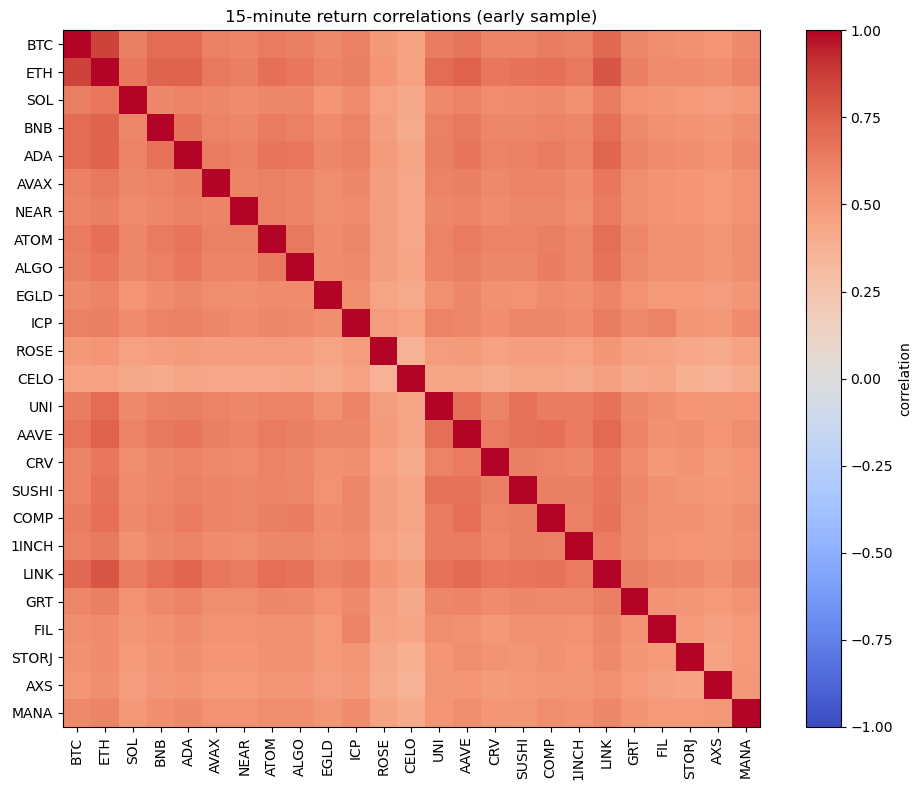

In [93]:
# Correlation of 15-minute returns (early sample)
corr = rets[rets.index < SPLIT.tz_localize(ET)].corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="correlation")
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("15-minute return correlations (early sample)")
plt.tight_layout(); plt.show()

## Part 1: Spot crypto, close window

**Primary specification, fixed in advance.** Each day, rank eligible assets by their 15:30–16:00 ET return. Go long the bottom decile and short the top decile, with at least one name per leg and equal counts on each side. Hold over 16:00–17:00 ET. An asset is eligible if its lagged 30-day ADV is at least the threshold set in the config.

,days,names/day,gross bps/d,cost bps/d,gross SR (early),gross SR (recent),net SR (recent)
strategy,,,,,,,
P1 close reversal,2212,3.8,3.77,55.55,+1.56 ± 0.50,+0.56 ± 0.71,-20.17 ± 0.88


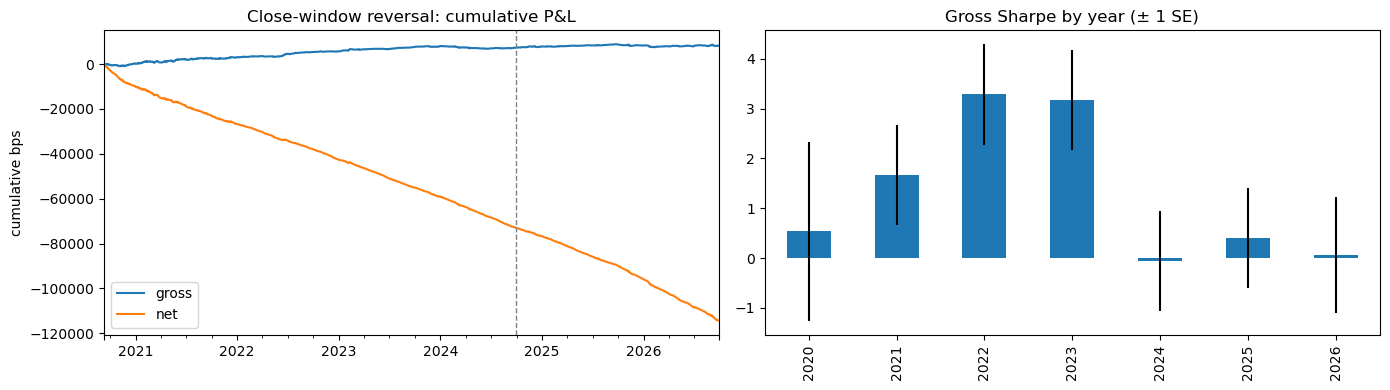

In [95]:
SIG_CLOSE, HOLD_CLOSE = ("15:30", "16:00"), ("16:00", "17:00")
close = run_xs("P1 close reversal", SIG_CLOSE, HOLD_CLOSE)
show(close)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
(close["gross"].cumsum() * 1e4).plot(ax=ax[0], label="gross")
(close["net"].cumsum() * 1e4).plot(ax=ax[0], label="net")
ax[0].axvline(SPLIT, color="grey", ls="--", lw=1); ax[0].set_ylabel("cumulative bps"); ax[0].legend()
ax[0].set_title("Close-window reversal: cumulative P&L")
yearly = close["gross"].groupby(close["gross"].index.year)
pd.DataFrame({"gross SR": yearly.apply(lambda x: sharpe(x, ANN_CRYPTO)),
              "SE": yearly.apply(lambda x: sharpe_se(x, ANN_CRYPTO))}).plot.bar(
    y="gross SR", yerr="SE", ax=ax[1], legend=False, title="Gross Sharpe by year (± 1 SE)")
plt.tight_layout(); plt.show()

### Is it bid-ask bounce?

A short-horizon reversal on bar closes is exactly what bid-ask bounce produces. If the last trade of the signal window prints at the bid, the next print is as likely to be at the ask, so the price appears to reverse even though nothing tradeable happened (Roll 1984). Three diagnostics separate bounce from an institutional-flow effect:

1. **Where the profit sits in the hold window.** Bounce is concentrated in the first bar after the signal. A flow-driven reversal should keep accruing afterwards.
2. **Spread size.** The Roll spread estimate shows how large the bounce component could be, and lets us check the assumed spread costs.
3. **Time of day.** If US-session flows drive the effect, windows anchored at 09:30 and 15:30 should stand out against the other 46 half-hours. Bounce would look much the same at every hour.

In [97]:
first_bar = run_xs("P1 close: first hold bar only", SIG_CLOSE, ("16:00", "16:15"), record=False)
skip_bar  = run_xs("P1 close: skip first hold bar", SIG_CLOSE, ("16:15", "17:00"))
display(pd.DataFrame([summarize(r) for r in (close, first_bar, skip_bar)]).set_index("strategy"))

recent_rets = rets[rets.index >= SPLIT.tz_localize(ET)]
spreads = pd.DataFrame({
    "tier": pd.Series(TIER),
    "assumed half-spread (bps)": pd.Series({c: HALF_SPREAD_BPS[TIER[c]] for c in TIER}),
    "Roll implied half-spread (bps)": roll_spread_bps(recent_rets) / 2,
    "lag-1 autocorr (15m)": recent_rets.apply(lambda s: s.autocorr(1)),
}).reindex(rets.columns).round(2)
display(spreads)

,days,names/day,gross bps/d,cost bps/d,gross SR (early),gross SR (recent),net SR (recent)
strategy,,,,,,,
P1 close reversal,2212,3.8,3.77,55.55,+1.56 ± 0.50,+0.56 ± 0.71,-20.17 ± 0.88
P1 close: first hold bar only,2212,3.8,3.92,55.55,+2.67 ± 0.50,+1.42 ± 0.71,-32.76 ± 1.11
P1 close: skip first hold bar,2212,3.8,-0.16,55.55,+0.03 ± 0.50,-0.28 ± 0.71,-23.47 ± 0.94


,tier,assumed half-spread (bps),Roll implied half-spread (bps),lag-1 autocorr (15m)
BTC,large,1.5,1.82,-0.01
ETH,large,1.5,NaN,0.00
SOL,large,1.5,5.22,-0.02
BNB,large,1.5,2.84,-0.01
ADA,mid,4.0,4.76,-0.01
AVAX,mid,4.0,4.73,-0.01
NEAR,mid,4.0,4.87,-0.01
ATOM,mid,4.0,3.91,-0.01
ALGO,mid,4.0,8.13,-0.02
EGLD,mid,4.0,15.49,-0.08


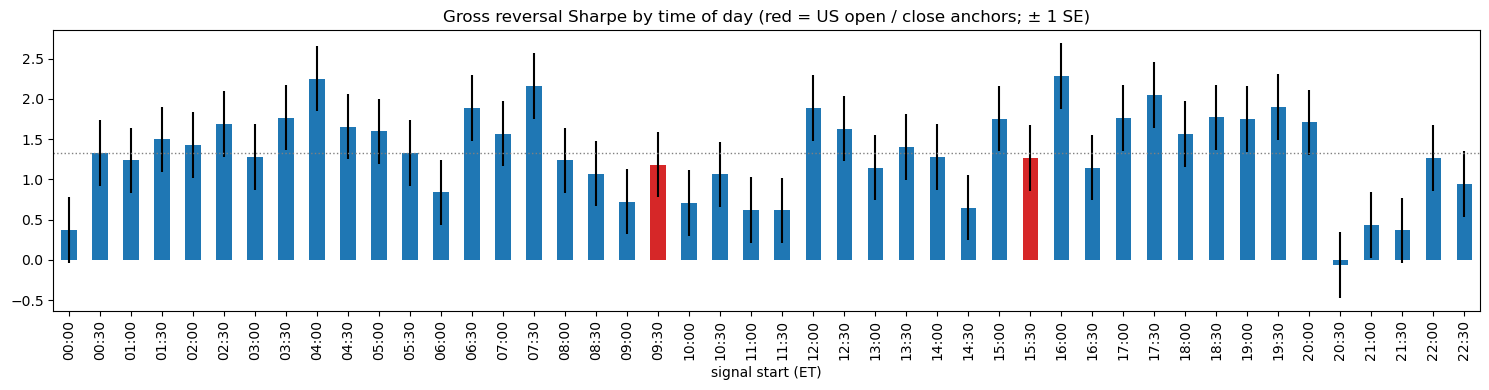

09:30 anchor: gross SR +1.18  — higher than 34% of the other 44 half-hour windows
15:30 anchor: gross SR +1.27  — higher than 41% of the other 44 half-hour windows


In [98]:
# Time-of-day profile: same design at every half-hour (signal 30m, hold next 60m)
rows = []
for start in range(0, 24 * 60 - 90 + 1, 30):
    s = f"{start // 60:02d}:{start % 60:02d}"
    m = f"{(start + 30) // 60:02d}:{(start + 30) % 60:02d}"
    e = f"{(start + 90) // 60:02d}:{(start + 90) % 60:02d}"
    r = run_xs(f"tod {s}", (s, m), (m, e), record=False)
    rows.append({"signal start (ET)": s, "gross SR": sharpe(r["gross"], ANN_CRYPTO),
                 "SE": sharpe_se(r["gross"], ANN_CRYPTO)})
tod_profile = pd.DataFrame(rows).set_index("signal start (ET)")

colors = ["tab:red" if t in ("09:30", "15:30") else "tab:blue" for t in tod_profile.index]
ax = tod_profile["gross SR"].plot.bar(yerr=tod_profile["SE"], color=colors, figsize=(15, 4))
ax.set_title("Gross reversal Sharpe by time of day (red = US open / close anchors; ± 1 SE)")
ax.axhline(tod_profile["gross SR"].median(), color="grey", ls=":", lw=1)
plt.tight_layout(); plt.show()

others = tod_profile.drop(["09:30", "15:30"])["gross SR"]
for anchor in ("09:30", "15:30"):
    pct = (others < tod_profile.loc[anchor, "gross SR"]).mean() * 100
    print(f"{anchor} anchor: gross SR {tod_profile.loc[anchor, 'gross SR']:+.2f}  "
          f"— higher than {pct:.0f}% of the other {len(others)} half-hour windows")

### Costs and capacity

The waterfall removes cost components one at a time over the recent two years. The capacity curve then holds the signal fixed and scales the book size.

In [100]:
recent = close["gross"].index >= SPLIT
g, c = close["gross"][recent], close["costs"][recent]
waterfall = pd.DataFrame({
    "bps/day": [g.mean() * 1e4, -c["commission"].mean() * 1e4, -c["spread"].mean() * 1e4,
                -c["impact"].mean() * 1e4],
    "SR after this step": [sharpe(g, ANN_CRYPTO),
                           sharpe(g - c["commission"], ANN_CRYPTO),
                           sharpe(g - c["commission"] - c["spread"], ANN_CRYPTO),
                           sharpe(g - c["total"], ANN_CRYPTO)],
}, index=["gross alpha", "commission", "spread", "impact"]).round(2)
display(waterfall)

cap = []
for aum in [10_000, 100_000, 1_000_000, 5_000_000, 25_000_000]:
    for mult in [1.0, 2.0]:
        cc = round_trip_costs(close["w"], ADV, VOL_BPS, aum=aum, impact_mult=mult)
        net = (close["gross"] - cc["total"])[recent]
        part = (close["w"].abs() * aum / ADV.reindex(index=close["w"].index, columns=close["w"].columns))
        part = part.where(close["w"] != 0).stack()
        cap.append({"AUM": f"${aum:,.0f}", "impact stress": f"{mult:.0f}x",
                    "median % of ADV per order": round(100 * part.median(), 3),
                    "impact bps/d": round(cc["impact"][recent].mean() * 1e4, 2),
                    "net SR (recent)": sr_txt(net, ANN_CRYPTO)})
display(pd.DataFrame(cap).set_index(["AUM", "impact stress"]))

,bps/day,SR after this step
gross alpha,1.46,0.56
commission,-15.00,-5.23
spread,-15.55,-11.10
impact,-27.65,-20.17


median % of ADV per order  impact bps/d net SR (recent)
AUM         impact stress                                                         
$10,000     1x                                 0.011          8.74   -14.23 ± 0.80
            2x                                 0.011         17.49   -17.13 ± 0.84
$100,000    1x                                 0.111         27.65   -20.17 ± 0.88
            2x                                 0.111         55.30   -26.51 ± 0.99
$1,000,000  1x                                 1.111         87.43   -30.93 ± 1.07
            2x                                 1.111        174.87   -35.35 ± 1.16
$5,000,000  1x                                 5.555        195.51   -35.73 ± 1.17
            2x                                 5.555        391.01   -36.71 ± 1.19
$25,000,000 1x                                27.775        437.17   -36.73 ± 1.19
            2x                                27.775        874.33   -36.59 ± 1.19

In [101]:
# Universe robustness
LARGE = ["BTC", "ETH", "SOL", "BNB"]
large = run_xs("P1 close, large caps only (1 per leg)", SIG_CLOSE, HOLD_CLOSE, cols=LARGE, frac=0.25)
ex_btc_eth = run_xs("P1 close, ex BTC & ETH", SIG_CLOSE, HOLD_CLOSE,
                    cols=[c for c in rets.columns if c not in ("BTC", "ETH")])
display(pd.DataFrame([summarize(r) for r in (close, large, ex_btc_eth)]).set_index("strategy"))

,days,names/day,gross bps/d,cost bps/d,gross SR (early),gross SR (recent),net SR (recent)
strategy,,,,,,,
P1 close reversal,2212,3.8,3.77,55.55,+1.56 ± 0.50,+0.56 ± 0.71,-20.17 ± 0.88
"P1 close, large caps only (1 per leg)",2212,2.0,1.24,24.57,+0.22 ± 0.50,+1.82 ± 0.71,-12.33 ± 0.78
"P1 close, ex BTC & ETH",2212,3.7,3.85,57.84,+1.60 ± 0.50,+0.47 ± 0.71,-21.09 ± 0.90


## Part 2: Spot crypto, open window

This applies the same design to the US open. Signal: 09:30–10:00 ET. Hold: 10:00–11:00 ET.

In [103]:
SIG_OPEN, HOLD_OPEN = ("09:30", "10:00"), ("10:00", "11:00")
opn       = run_xs("P2 open reversal", SIG_OPEN, HOLD_OPEN)
opn_first = run_xs("P2 open: first hold bar only", SIG_OPEN, ("10:00", "10:15"), record=False)
opn_skip  = run_xs("P2 open: skip first hold bar", SIG_OPEN, ("10:15", "11:00"))
display(pd.DataFrame([summarize(r) for r in (opn, opn_first, opn_skip)]).set_index("strategy"))

both = pd.concat({"close": close["gross"], "open": opn["gross"]}, axis=1).dropna()
print(f"Daily gross P&L correlation, close vs open: {both.corr().iloc[0, 1]:.3f}  (n={len(both)})")

,days,names/day,gross bps/d,cost bps/d,gross SR (early),gross SR (recent),net SR (recent)
strategy,,,,,,,
P2 open reversal,2210,3.8,4.15,54.39,+0.87 ± 0.50,+2.02 ± 0.71,-16.07 ± 0.82
P2 open: first hold bar only,2210,3.8,3.38,54.39,+1.41 ± 0.50,+2.26 ± 0.71,-28.13 ± 1.02
P2 open: skip first hold bar,2210,3.8,0.77,54.39,+0.04 ± 0.50,+0.86 ± 0.71,-19.99 ± 0.88


Daily gross P&L correlation, close vs open: 0.041  (n=2210)


### Hold-window sweep, selected out of sample

For both anchors, the hold start (0, 15 or 30 minutes after the signal) and duration (15–120 minutes) are chosen on the **early** sample using net-of-commission Sharpe. The chosen window is then evaluated once on the **recent** two years. The Deflated Sharpe Ratio gives the probability that the early-sample winner has a true Sharpe above zero after accounting for every window tried.

In [105]:
def add(t, m):
    x = hhmm(t) + m
    return f"{x // 60:02d}:{x % 60:02d}"

def comm_net(r):
    return r["gross"] - 2 * COMMISSION_BPS / 1e4 * r["w"].abs().sum(axis=1)

sweep_rows = []
for label, sig_win in [("close", SIG_CLOSE), ("open", SIG_OPEN)]:
    trials = []
    for gap in [0, 15, 30]:
        for dur in [15, 30, 60, 90, 120]:
            hs = add(sig_win[1], gap); he = add(hs, dur)
            r = run_xs(f"{label} {hs}-{he}", sig_win, (hs, he), record=False)
            x = comm_net(r)
            trials.append((hs, he, r, sharpe(x[x.index < SPLIT], ANN_CRYPTO)))
    hs, he, best, best_sr = max(trials, key=lambda t: t[3])
    x = comm_net(best)
    dsr, sr0, n_trials = deflated_sharpe(x[x.index < SPLIT], [t[3] for t in trials], ANN_CRYPTO)
    sweep_rows.append({
        "anchor": label, "selected hold": f"{hs}-{he}", "trials": n_trials,
        "early SR (selected)": round(best_sr, 2),
        "expected max SR under null": round(sr0, 2),
        "deflated SR (prob.)": round(dsr, 3),
        "recent SR, after commission": sr_txt(x[x.index >= SPLIT], ANN_CRYPTO),
        "recent SR, full costs": sr_txt(best["net"][best["net"].index >= SPLIT], ANN_CRYPTO),
    })
display(pd.DataFrame(sweep_rows).set_index("anchor"))

,selected hold,trials,early SR (selected),expected max SR under null,deflated SR (prob.),"recent SR, after commission","recent SR, full costs"
anchor,,,,,,,
close,16:00-18:00,15,-1.29,4.35,0.0,-3.58 ± 0.71,-14.71 ± 0.80
open,10:00-11:30,15,-1.84,3.39,0.0,-2.80 ± 0.71,-13.92 ± 0.79


## Part 3: Spot BTC and ETH ETFs

ETFs have a hard 16:00 close and much thinner after-hours trading. The data are Yahoo Finance 60-minute bars over two years, including pre- and post-market. In the regular session, bars start at 09:30, 10:30, … 15:30, and the 15:30 bar covers 15:30–16:00. After hours, bars start on the hour from 16:00 to 19:00. Each bar's length is inferred from the session schedule, so windows only ever contain complete bars. Early-close days produce off-grid bars, so those days drop out of any window they don't fully cover.

Three pre-registered tests:
- **E1, BTC vs ETH relative momentum into the close.** IBIT vs ETHA, one long and one short. Signal is the 15:30–16:00 return; hold over 16:00–17:00 after hours.
- **E2, twin-ETF placebo.** The same trade on IBIT vs FBTC. They hold the same asset, so the economic prior is zero. Any non-zero result measures how much microstructure noise (stale or bouncing after-hours prints) can produce on its own, and that sets the bar E1 has to clear.
- **E3, intraday time-series momentum (Gao et al. 2018).** Signal is the return from the prior 16:00 close to 10:30. Take the sign of that return as the position in the 15:30–16:00 bar, run separately for IBIT and ETHA. It is compared against simply being long in that bar, which shows how much of the result is just market direction.

ETF costs are charged per side on every round trip, and the sensitivity grid shows how far they could rise.

In [107]:
def load_yf(tickers, interval="60m", days=720):
    # Yahoo serves intraday hourly bars for the last 730 days only; stay safely inside that limit.
    path = CACHE_DIR / f"yf_{'-'.join(tickers)}_{interval}_{days}d.pkl"
    if path.exists():
        return pd.read_pickle(path)
    import yfinance as yf
    start = (pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=days)).strftime("%Y-%m-%d")
    raw_yf = yf.download(tickers, interval=interval, start=start, prepost=True, auto_adjust=True,
                         group_by="ticker", progress=False, threads=True)
    px = pd.DataFrame({t: raw_yf[t]["Close"] for t in tickers}).dropna(how="all")
    if px.empty:
        raise RuntimeError("Yahoo returned no ETF data. Re-run this cell; if it persists, check yfinance is up to date.")
    px.to_pickle(path)
    return px

etf_px = load_yf(ETF_TICKERS)
etf_px = etf_px.tz_localize("UTC").tz_convert(ET) if etf_px.index.tz is None else etf_px.tz_convert(ET)
etf_px = etf_px.sort_index()
etf_px = etf_px[~etf_px.index.duplicated(keep="last")]

def session_bar_len(idx, nominal=60):
    # Bar length in minutes: nominal, truncated at session boundaries (09:30, 16:00, 20:00).
    t = tod(idx)
    nxt = t + nominal
    for b in (hhmm("09:30"), hhmm("16:00"), hhmm("20:00")):
        nxt = np.where((t < b) & (nxt > b), b, nxt)
    return pd.Series(nxt - t, index=idx)

ETF_BAR = session_bar_len(etf_px.index)
etf_rets = np.log(etf_px).diff()
print(f"ETF panel {etf_px.shape} | {etf_px.index[0]:%Y-%m-%d} → {etf_px.index[-1]:%Y-%m-%d}")
print("Bar start times seen:", sorted({f"{t // 60:02d}:{t % 60:02d}" for t in tod(etf_px.index)}))

def etf_cost(zone, override=None):
    return (ETF_COST_BPS[zone] if override is None else override) / 1e4

def pair_trade(a, b, sig_win, hold_win, direction=+1, zone="after_hours", cost_bps=None):
    check_disjoint(sig_win, hold_win)
    r = etf_rets[[a, b]]
    sig  = window_sum(r, *sig_win, ETF_BAR)
    hold = window_sum(r, *hold_win, ETF_BAR)
    d = sig.dropna().index.intersection(hold.dropna().index)
    w = xs_weights(sig.loc[d], frac=0.5, direction=direction)
    gross = (w * hold.loc[d]).sum(axis=1)
    cost  = 2 * etf_cost(zone, cost_bps) * w.abs().sum(axis=1)       # open + close every day
    return dict(name=f"{a} vs {b} ({'mom' if direction > 0 else 'rev'})", w=w, gross=gross,
                costs=pd.DataFrame({"total": cost}), net=gross - cost, ann=ANN_ETF)

def price_at(px, hm):
    # Price at clock time hm = close of the bar that ends at hm.
    ends = tod(px.index) + ETF_BAR.reindex(px.index).values
    sub = px[ends == hhmm(hm)]
    return sub.groupby(day_of(sub.index)).last()

def gao_momentum(ticker, cost_bps=None):
    p16  = price_at(etf_px[[ticker]], "16:00")[ticker]
    p1030 = price_at(etf_px[[ticker]], "10:30")[ticker]
    signal = np.log(p1030) - np.log(p16.shift(1))             # prior close → 10:30
    hold = window_sum(etf_rets[[ticker]], "15:30", "16:00", ETF_BAR)[ticker]
    d = signal.dropna().index.intersection(hold.dropna().index)
    pos = np.sign(signal.loc[d])
    gross = pos * hold.loc[d]
    cost = 2 * etf_cost("regular", cost_bps) * pos.abs()
    always_long = hold.loc[d] - 2 * etf_cost("regular", cost_bps)
    return dict(name=f"E3 Gao momentum {ticker}", w=pos.to_frame(ticker), gross=gross,
                costs=pd.DataFrame({"total": cost}), net=gross - cost, ann=ANN_ETF,
                always_long=always_long)

def etf_row(res, label):
    g, n = res["gross"], res["net"]
    return {"strategy": label, "days": len(g), "gross bps/d": round(g.mean() * 1e4, 2),
            "gross SR": sr_txt(g, ANN_ETF), "net SR": sr_txt(n, ANN_ETF),
            "max |net exposure|": round(res["w"].sum(axis=1).abs().max(), 2)}

E_SIG, E_HOLD = ("15:30", "16:00"), ("16:00", "17:00")
e1 = pair_trade("IBIT", "ETHA", E_SIG, E_HOLD, direction=+1)
e2 = pair_trade("IBIT", "FBTC", E_SIG, E_HOLD, direction=+1)
e3 = {t: gao_momentum(t) for t in ("IBIT", "ETHA")}

etf_table = [etf_row(e1, "E1 BTC vs ETH momentum (IBIT/ETHA)"),
             etf_row(e2, "E2 twin placebo (IBIT/FBTC)")]
for t, r in e3.items():
    etf_table.append(etf_row(r, f"E3 Gao momentum {t}"))
    etf_table.append({"strategy": f"   control: always long {t} 15:30-16:00", "days": len(r["always_long"]),
                      "gross bps/d": round((r["always_long"] + 2 * etf_cost('regular')).mean() * 1e4, 2),
                      "gross SR": "", "net SR": sr_txt(r["always_long"], ANN_ETF), "max |net exposure|": 1.0})
etf_table = pd.DataFrame(etf_table).set_index("strategy")
display(etf_table)

sens = []
for bps in [0, 1, 2, 5, 10]:
    sens.append({"cost per side (bps)": bps,
                 "E1 net SR": sr_txt(pair_trade("IBIT", "ETHA", E_SIG, E_HOLD, +1, cost_bps=bps)["net"], ANN_ETF),
                 "E3 IBIT net SR": sr_txt(gao_momentum("IBIT", cost_bps=bps)["net"], ANN_ETF),
                 "E3 ETHA net SR": sr_txt(gao_momentum("ETHA", cost_bps=bps)["net"], ANN_ETF)})
display(pd.DataFrame(sens).set_index("cost per side (bps)"))

for res, label in [(e1, "E1"), (e2, "E2"), (e3["IBIT"], "E3 IBIT"), (e3["ETHA"], "E3 ETHA")]:
    RESULTS.append({"strategy": label, "days": len(res["gross"]),
                    "gross bps/d": round(res["gross"].mean() * 1e4, 2),
                    "cost bps/d": round(res["costs"]["total"].mean() * 1e4, 2),
                    "gross SR (recent)": sr_txt(res["gross"], ANN_ETF),
                    "net SR (recent)": sr_txt(res["net"], ANN_ETF)})

ETF panel (8179, 4) | 2024-10-17 → 2026-10-07
Bar start times seen: ['04:00', '05:00', '06:00', '07:00', '08:00', '09:00', '09:30', '10:30', '11:30', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00', '17:00', '18:00', '19:00']


,days,gross bps/d,gross SR,net SR,max |net exposure|
strategy,,,,,
E1 BTC vs ETH momentum (IBIT/ETHA),487,-1.11,-0.68 ± 0.72,-6.83 ± 0.75,0.0
E2 twin placebo (IBIT/FBTC),487,-0.74,-2.87 ± 0.73,-41.36 ± 1.51,0.0
E3 Gao momentum IBIT,485,-0.33,-0.13 ± 0.72,-0.93 ± 0.72,1.0
control: always long IBIT 15:30-16:00,485,-1.69,,-1.48 ± 0.72,1.0
E3 Gao momentum ETHA,485,-3.04,-0.95 ± 0.72,-1.57 ± 0.72,1.0
control: always long ETHA 15:30-16:00,485,-0.10,,-0.65 ± 0.72,1.0


,E1 net SR,E3 IBIT net SR,E3 ETHA net SR
cost per side (bps),,,
0,-0.68 ± 0.72,-0.13 ± 0.72,-0.95 ± 0.72
1,-1.91 ± 0.72,-0.93 ± 0.72,-1.57 ± 0.72
2,-3.14 ± 0.73,-1.73 ± 0.72,-2.19 ± 0.72
5,-6.83 ± 0.75,-4.13 ± 0.73,-4.05 ± 0.73
10,-12.97 ± 0.83,-8.12 ± 0.77,-7.16 ± 0.76


### Exploratory ETF sweep, deflated

This sweep tries every adjacent signal/hold bar pair in the regular and after-hours sessions, for both the BTC–ETH pair and IBIT time-series momentum, in both directions. Two years of ETF data cannot support a hold-out split. The Deflated Sharpe Ratio is therefore the main guard here: it asks whether the best result beats what the luckiest of N noise strategies would show.

In [109]:
bar_starts = sorted(set(tod(etf_px.index)))
bar_starts = [f"{t // 60:02d}:{t % 60:02d}" for t in bar_starts if hhmm("09:30") <= t < hhmm("20:00")]
bar_len_at = {s: int(ETF_BAR[tod(ETF_BAR.index) == hhmm(s)].mode().iloc[0]) for s in bar_starts}

def ts_trade(ticker, sig_win, hold_win, direction, zone):
    r = etf_rets[[ticker]]
    sig = window_sum(r, *sig_win, ETF_BAR)[ticker]
    hold = window_sum(r, *hold_win, ETF_BAR)[ticker]
    d = sig.dropna().index.intersection(hold.dropna().index)
    pos = direction * np.sign(sig.loc[d])
    gross = pos * hold.loc[d]
    return gross, gross - 2 * etf_cost(zone) * pos.abs()

# Selection and deflation use GROSS returns (is there any signal at all?); net shown alongside.
trials = {}
for s1, s2 in zip(bar_starts[:-1], bar_starts[1:]):
    sig_win  = (s1, add(s1, bar_len_at[s1]))
    hold_win = (s2, add(s2, bar_len_at[s2]))
    if hhmm(sig_win[1]) != hhmm(s2):
        continue                                   # not adjacent (gap in the bar grid)
    zone = "regular" if hhmm(s2) < hhmm("16:00") else "after_hours"
    for direction in (+1, -1):
        tag = f"{sig_win[0]}->{hold_win[0]} {'mom' if direction > 0 else 'rev'}"
        p = pair_trade("IBIT", "ETHA", sig_win, hold_win, direction, zone)
        trials[f"pair {tag}"] = (p["gross"], p["net"])
        trials[f"IBIT ts {tag}"] = ts_trade("IBIT", sig_win, hold_win, direction, zone)

trial_tbl = pd.DataFrame({k: {"gross SR": sharpe(g, ANN_ETF), "net SR": sharpe(n, ANN_ETF), "days": len(g)}
                          for k, (g, n) in trials.items()}).T
trial_tbl = trial_tbl[trial_tbl["days"] >= 100].sort_values("gross SR", ascending=False)
best_key = trial_tbl.index[0]
best_gross, best_net = trials[best_key]
dsr, sr0, n_trials = deflated_sharpe(best_gross, trial_tbl["gross SR"].values, ANN_ETF)
print(f"{n_trials} trials (≥100 days). Best by gross SR: {best_key}  gross {sr_txt(best_gross, ANN_ETF)}, "
      f"net {sr_txt(best_net, ANN_ETF)}")
print(f"Expected best gross SR from {n_trials} zero-skill trials: {sr0:.2f}  →  deflated SR probability {dsr:.3f}")
display(trial_tbl.head(10).round(2))

28 trials (≥100 days). Best by gross SR: pair 17:00->18:00 rev  gross +3.80 ± 0.73, net -2.97 ± 0.73
Expected best gross SR from 28 zero-skill trials: 3.05  →  deflated SR probability 0.826


,gross SR,net SR,days
pair 17:00->18:00 rev,3.80,-2.97,484.0
pair 18:00->19:00 rev,2.49,-5.99,321.0
pair 16:00->17:00 rev,1.55,-4.51,487.0
IBIT ts 17:00->18:00 rev,1.47,-2.13,484.0
IBIT ts 10:30->11:30 mom,1.42,0.93,491.0
IBIT ts 16:00->17:00 rev,1.12,-2.55,487.0
pair 10:30->11:30 mom,0.74,-0.54,491.0
pair 15:30->16:00 rev,0.68,-5.46,487.0
IBIT ts 15:30->16:00 rev,0.40,-2.94,487.0
IBIT ts 11:30->12:30 mom,0.34,-0.15,486.0


## Results summary

In [111]:
summary = pd.DataFrame(RESULTS).set_index("strategy")
summary = summary.astype(object).where(summary.notna(), "—")
print(f"Crypto: early = before {SPLIT:%Y-%m-%d}, recent = after.  ETFs (E1–E3): full ~2-year sample "
      f"shown in the 'recent' columns.  Sharpe ratios annualised, ± 1 standard error.")
display(summary)

Crypto: early = before 2024-09-30, recent = after.  ETFs (E1–E3): full ~2-year sample shown in the 'recent' columns.  Sharpe ratios annualised, ± 1 standard error.


,days,names/day,gross bps/d,cost bps/d,gross SR (early),gross SR (recent),net SR (recent)
strategy,,,,,,,
P1 close reversal,2212,3.8,3.77,55.55,+1.56 ± 0.50,+0.56 ± 0.71,-20.17 ± 0.88
P1 close: skip first hold bar,2212,3.8,-0.16,55.55,+0.03 ± 0.50,-0.28 ± 0.71,-23.47 ± 0.94
"P1 close, large caps only (1 per leg)",2212,2.0,1.24,24.57,+0.22 ± 0.50,+1.82 ± 0.71,-12.33 ± 0.78
"P1 close, ex BTC & ETH",2212,3.7,3.85,57.84,+1.60 ± 0.50,+0.47 ± 0.71,-21.09 ± 0.90
P2 open reversal,2210,3.8,4.15,54.39,+0.87 ± 0.50,+2.02 ± 0.71,-16.07 ± 0.82
P2 open: skip first hold bar,2210,3.8,0.77,54.39,+0.04 ± 0.50,+0.86 ± 0.71,-19.99 ± 0.88
E1,487,—,-1.11,10.0,—,-0.68 ± 0.72,-6.83 ± 0.75
E2,487,—,-0.74,10.0,—,-2.87 ± 0.73,-41.36 ± 1.51
E3 IBIT,485,—,-0.33,1.99,—,-0.13 ± 0.72,-0.93 ± 0.72


## Findings

All figures come from the run above: global Binance spot, September 2020 – September 2026, with the recent hold-out starting October 2024. Sharpe ratios are annualised and shown ± 1 standard error.

**1. The gross reversal is real but small, and it is bid-ask bounce.** The close-window reversal earns about 3.8 bps a day before costs. That is a gross Sharpe of +1.56 ± 0.50 in the early sample and +0.56 ± 0.71 in the last two years. The whole effect sits in the first 15-minute bar after the signal (first bar alone: +2.67 ± 0.50 early). Skip that one bar and the effect disappears (+0.03 ± 0.50 early, −0.28 ± 0.71 recent). The open window behaves the same way: +0.04 ± 0.50 in the early sample once the first bar is skipped. All 25 assets show negative lag-one autocorrelation in 15-minute returns, strongest in the least liquid names (FIL −0.11, EGLD −0.08). The Roll-implied half-spreads of roughly 2–22 bps are what bounce of this size requires, and they line up with the assumed cost tiers.

**2. The US open and close are not special.** Run at every half-hour of the day, the same reversal looks much the same. The 15:30 anchor beats only about 41% of the other 44 windows, and 09:30 about 34%. The pattern is generic short-horizon microstructure, not an institutional-flow footprint tied to US equity hours, so the motivating hypothesis is rejected.

**3. Nothing here is tradeable.** Recent gross alpha of about 1.5 bps a day is a tenth of commission alone (15 bps a day for a round trip at 7.5 bps per side). Net Sharpe is strongly negative at every book size, including about −14 with a $10k book. Hold windows selected on the early sample also fail out of sample, with a Deflated Sharpe probability of about zero.

**4. The spot BTC/ETH ETFs show no intraday effect.** BTC-vs-ETH relative momentum into the close has a gross Sharpe of −0.68 ± 0.72. Gao-style intraday momentum is −0.13 ± 0.72 for IBIT and −0.95 ± 0.72 for ETHA, no different from simply holding the last half-hour. The twin-ETF placebo (IBIT vs FBTC, the same underlying asset) has a gross Sharpe of −2.87 ± 0.73. Noise in after-hours prints is enough on its own to produce Sharpe ratios of that size, which is why an after-hours result has to clear the placebo, not zero. The strongest result in the exploratory sweep is an after-hours BTC-vs-ETH *reversal* (signal 17:00–18:00, hold 18:00–19:00: gross Sharpe +3.80 ± 0.73). Deflated for the 28 windows tried, the probability that its true Sharpe is positive is 0.83, below the conventional 0.95 bar. It also sits in the same thin after-hours bars where the twin-ETF placebo produces a reversal of +2.87 between two funds holding the same asset, so most of it is plausibly print noise. At 5 bps per side for after-hours execution, it loses money (net −2.97).

**Note on an earlier version.** A previous version of this notebook reported ETF momentum Sharpe ratios of 3–8. Those came from three errors, all fixed here:
- the signal and hold windows shared a bar;
- the "long/short" books were in fact 50–100% net long BTC/ETH during a rising market;
- costs were charged only on weight changes rather than on each daily round trip.

**Takeaway.** The measurable short-horizon reversal in crypto is compensation for providing liquidity across the bid-ask spread, not a predictable flow effect. A strategy that crosses the spread to capture it pays more than it earns. The same signal would only be worth studying from the passive side: as a market maker quoting both sides, or with limit-order fill modelling, which bar data can't support.

## Limitations

- **Bar data, not quotes.** Returns come from 15-minute (crypto) and 60-minute (ETF) closing prices. Spread costs are tier assumptions, cross-checked against Roll estimates but not measured from order-book data. A quote-level replication would settle the bounce question directly.
- **One venue.** Liquidity, spreads and bounce differ across exchanges. Capacity numbers apply to the chosen source only, and Binance.US is far thinner than global Binance.
- **Impact model.** The square-root law with Y = 0.5 is a standard approximation (Tóth et al. 2011). It isn't calibrated to these assets, which is why a 2x stress case is shown.
- **ETF sample.** About two years of hourly data exist, so ETF results come from a single regime and have wide error bands. After-hours prints on Yahoo Finance can be stale. The twin-ETF placebo is there to measure that.
- **Survivorship.** The crypto universe is a fixed list chosen in 2020. Several names have since lost most of their liquidity. The lagged ADV filter removes them as they fade, but it doesn't remove the bias in which names were picked originally.

## References

- Bailey, D. H., & López de Prado, M. (2014). The Deflated Sharpe Ratio. *Journal of Portfolio Management*, 40(5), 94–107.
- Bogousslavsky, V. (2016). Infrequent Rebalancing, Return Autocorrelation, and Seasonality. *Journal of Finance*, 71(6), 2967–3006.
- Gao, L., Han, Y., Li, S. Z., & Zhou, G. (2018). Market Intraday Momentum. *Journal of Financial Economics*, 129(2), 394–414.
- Heston, S. L., Korajczyk, R. A., & Sadka, R. (2010). Intraday Patterns in the Cross-section of Stock Returns. *Journal of Finance*, 65(4), 1369–1407.
- Lo, A. W. (2002). The Statistics of Sharpe Ratios. *Financial Analysts Journal*, 58(4), 36–52.
- Roll, R. (1984). A Simple Implicit Measure of the Effective Bid-Ask Spread. *Journal of Finance*, 39(4), 1127–1139.
- Tóth, B., et al. (2011). Anomalous Price Impact and the Critical Nature of Liquidity in Financial Markets. *Physical Review X*, 1, 021006.